# Kepler Orbits, Comets, and Three-Body Perturbations

Bound and unbound orbits, comet periods, and Earth–Jupiter perturbations with fixed and mobile Sun models.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Mercury orbit parameters from rp, ra:
  a = 0.387000 AU,   e = 0.206718
Speeds at r0 = rp:
  v_peri(real Mercury) = 12.457005 AU/yr
  v_circ               = 11.339938 AU/yr
  v_parabolic(escape)  = 16.037094 AU/yr
  v_hyperbolic         = 17.640804 AU/yr

Initial specific energies (per unit mass):
  Real Mercury:  -51.005707
  Circular:      -64.297097
  Parabolic:     0.000000
  Hyperbolic:    27.004781

Measured r_min, r_max: 0.30699746734141076 0.4670084021547939
Expected rp, ra: 0.307 0.467


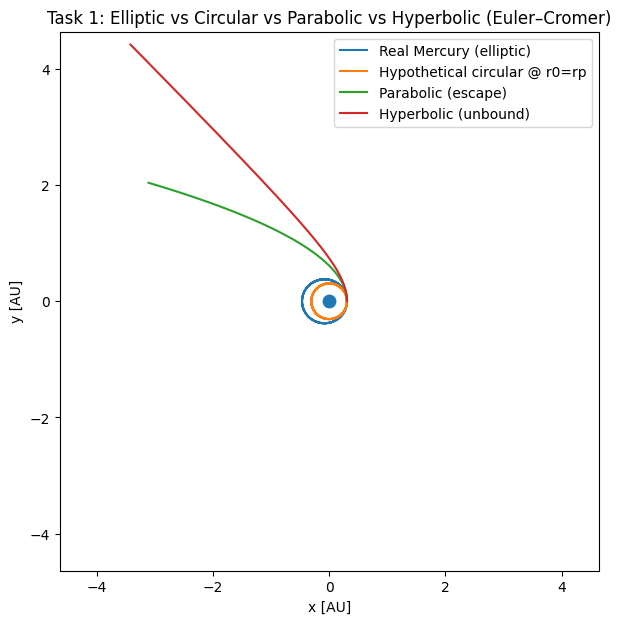

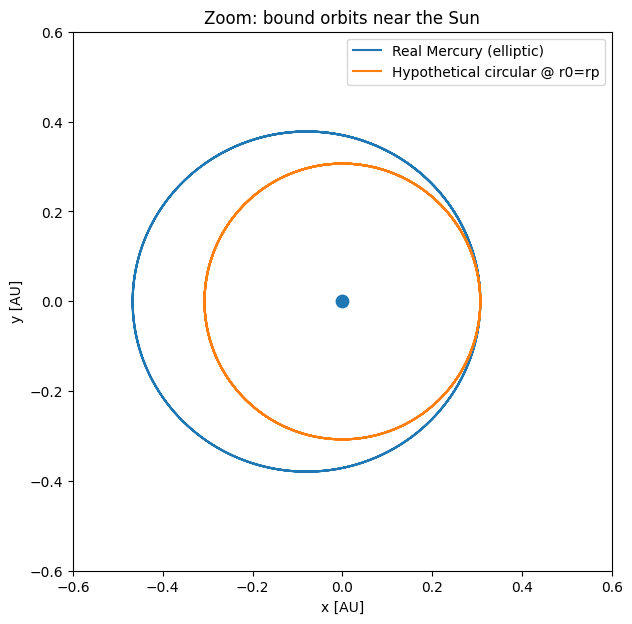

In [ ]:

import numpy as np;
import matplotlib.pyplot as plt;

# Euler–Cromer
def orbit_euler_cromer(x0, y0, vx0, vy0, dt, t_end, GM = 4*np.pi**2, beta = 2.0, alpha = 0.0):
    # Integrate motion in the x-y plane under central force: r¨ = -GM * (1 + alpha/r^2) * r_vec / r^(beta + 1)
    # For Newtonian gravity: beta = 2, alpha = 0
    nsteps = int(np.round(t_end / dt));
    t = np.linspace(0.0, nsteps*dt, nsteps +1);

    x = np.zeros(nsteps+1); y = np.zeros(nsteps+1);
    vx = np.zeros(nsteps+1); vy = np.zeros(nsteps+1);

    x[0], y[0], vx[0], vy[0] = x0, y0, vx0, vy0;

    for i in range(nsteps):
        r = np.sqrt(x[i]**2 + y[i]**2);
        # acceleration factor points inward
        fac = -GM * (1.0 + alpha/(r*r)) / (r**(beta+1.0));

        ax = fac * x[i];
        ay = fac * y[i];

        # EC: update velocity first
        vx[i+1] = vx[i] + ax*dt;
        vy[i+1] = vy[i] + ay*dt;
        # now update position using new velocity
        x[i+1] = x[i] + vx[i+1]*dt;
        y[i+1] = y[i] + vy[i+1]*dt;

    return t, x, y, vx, vy;

def specific_energy(x, y, vx, vy, GM = 4*np.pi**2):
    r = np.sqrt(x**2 + y**2);
    v2 = vx**2 + vy**2;
    # Energy per unit mass
    return 0.5*v2 - GM/r;

# Choose Mercury
GM = 4*np.pi**2;

rp = 0.307;   # perihelion [AU]
ra = 0.467;   # aphelion  [AU]
a  = 0.5*(rp + ra);
e  = (ra - rp)/(ra + rp);

# Start at perihelion on +x axis, purely tangential velocity +y direction
x0, y0 = rp, 0.0;
vx0 = 0.0;

# Real Mercury perihelion speed from vis-viva:
vp = np.sqrt(GM*(2.0/rp - 1.0/a));

# Hypothetical speeds at the SAME starting radius rp:
v_circ = np.sqrt(GM/rp);
v_para = np.sqrt(2.0*GM/rp);
v_hyp  = 1.10*v_para;

print("Mercury orbit parameters from rp, ra:");
print(f"  a = {a:.6f} AU,   e = {e:.6f}");
print("Speeds at r0 = rp:");
print(f"  v_peri(real Mercury) = {vp:.6f} AU/yr");
print(f"  v_circ               = {v_circ:.6f} AU/yr");
print(f"  v_parabolic(escape)  = {v_para:.6f} AU/yr");
print(f"  v_hyperbolic         = {v_hyp:.6f} AU/yr");

# Run the simulations
dt = 1e-4;          # ~0.0365 days
t_end_real = 0.80;  # ~3.3 Mercury periods
t_end_open = 0.60;  # make it enough to see escape

# Real Mercury -> elliptical
t1, x1, y1, vx1, vy1 = orbit_euler_cromer(x0, y0, vx0, vp, dt, t_end_real, GM = GM);
# Circular
t2, x2, y2, vx2, vy2 = orbit_euler_cromer(x0, y0, vx0, v_circ, dt, t_end_real, GM = GM);
# Parabolic
t3, x3, y3, vx3, vy3 = orbit_euler_cromer(x0, y0, vx0, v_para, dt, t_end_open, GM = GM);
# Hyperbolic
t4, x4, y4, vx4, vy4 = orbit_euler_cromer(x0, y0, vx0, v_hyp, dt, t_end_open, GM = GM);

# Energies should be <0, <0, ~0, >0
E1 = specific_energy(x1, y1, vx1, vy1, GM = GM)[0];
E2 = specific_energy(x2, y2, vx2, vy2, GM = GM)[0];
E3 = specific_energy(x3, y3, vx3, vy3, GM = GM)[0];
E4 = specific_energy(x4, y4, vx4, vy4, GM = GM)[0];
print("\nInitial specific energies (per unit mass):");
print(f"  Real Mercury:  {E1:.6f}");
print(f"  Circular:      {E2:.6f}");
print(f"  Parabolic:     {E3:.6f}");
print(f"  Hyperbolic:    {E4:.6f}");
r = np.sqrt(x1**2 + y1**2);
print("\nMeasured r_min, r_max:", r.min(), r.max());
print("Expected rp, ra:", rp, ra);

# Plot: overview (includes escape)
fig, ax = plt.subplots(figsize = (7,7));
ax.plot(x1, y1, label = "Real Mercury (elliptic)");
ax.plot(x2, y2, label = "Hypothetical circular @ r0=rp");
ax.plot(x3, y3, label = "Parabolic (escape)");
ax.plot(x4, y4, label = "Hyperbolic (unbound)");

# Sun marker
ax.scatter([0],[0], s = 80);
ax.set_aspect('equal', 'box');
ax.set_xlabel("x [AU]");
ax.set_ylabel("y [AU]");
ax.set_title("Task 1: Elliptic vs Circular vs Parabolic vs Hyperbolic (Euler–Cromer)");

# Reasonable axis limits
allx = np.concatenate([x1, x2, x3, x4]);
ally = np.concatenate([y1, y2, y3, y4]);
Rmax = 1.05*max(np.max(np.abs(allx)), np.max(np.abs(ally)));
Rmax = min(Rmax, 6.0)  # j cap it so plot stays readable
ax.set_xlim(-Rmax, Rmax);
ax.set_ylim(-Rmax, Rmax);
ax.legend();
plt.show();

# Ploting the zoom near the Sun (just bound orbits)
fig, ax = plt.subplots(figsize = (7,7));
ax.plot(x1, y1, label = "Real Mercury (elliptic)");
ax.plot(x2, y2, label = "Hypothetical circular @ r0=rp");
ax.scatter([0],[0], s = 80);
ax.set_aspect('equal', 'box');
ax.set_xlabel("x [AU]");
ax.set_ylabel("y [AU]");
ax.set_title("Zoom: bound orbits near the Sun");
ax.set_xlim(-0.6, 0.6);
ax.set_ylim(-0.6, 0.6);
ax.legend();
plt.show();

#EOF




Shoemaker–Levy 2 (given elements)
  Inputs: q = 1.933000 AU, e = 0.572000
  a = q/(1-e) = 4.516355 AU
  v_peri (from vis-viva) = 5.666178 AU/yr
  Theoretical period T_th = a^(3/2) = 9.598031 yr
  Simulated period   T_sim = 9.598500 yr
  Perihelion check: r_peri_sim = 1.932999 AU (should be ~q)
  Kepler ratio from sim: T_sim^2 / a^3 = 1.000098 (should be ~1)


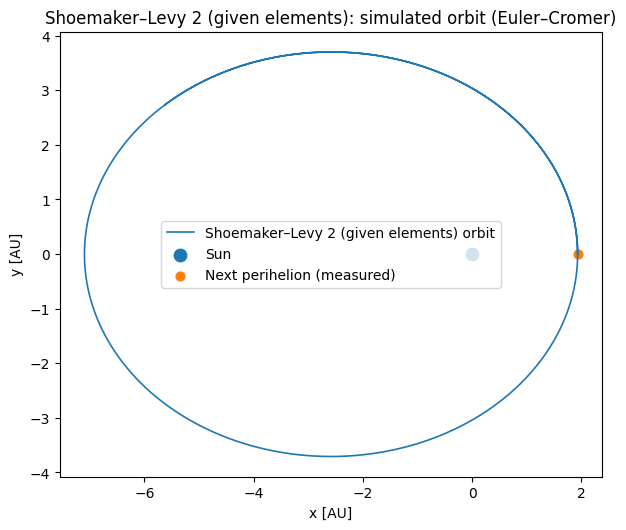

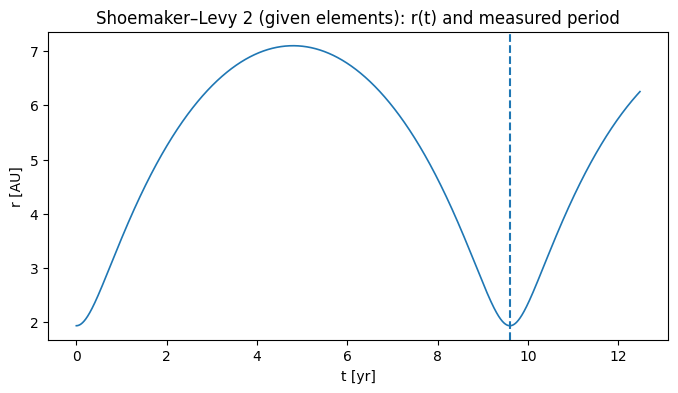


Halley's Comet (given elements)
  Inputs: q = 0.589000 AU, e = 0.967000
  a = q/(1-e) = 17.848485 AU
  v_peri (from vis-viva) = 11.482181 AU/yr
  Theoretical period T_th = a^(3/2) = 75.405328 yr
  Simulated period   T_sim = 75.734000 yr
  Perihelion check: r_peri_sim = 0.588999 AU (should be ~q)
  Kepler ratio from sim: T_sim^2 / a^3 = 1.008736 (should be ~1)


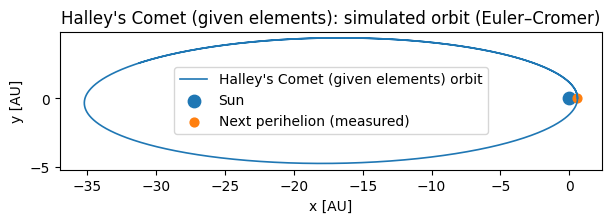

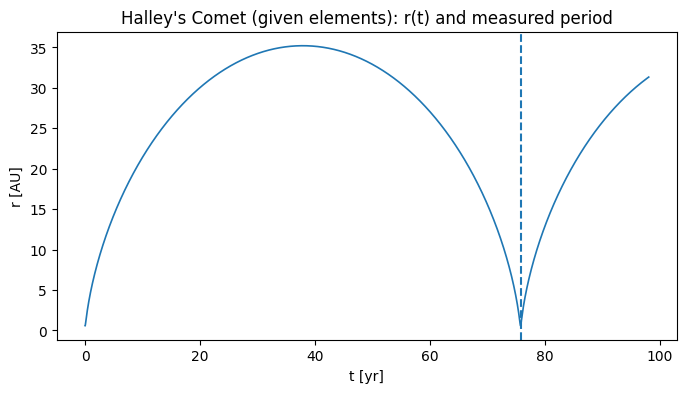


Kepler's 3rd law check (simulation):
  SL2:    T^2/a^3 = 1.000098
  Halley: T^2/a^3 = 1.008736


In [ ]:

import numpy as np;
import matplotlib.pyplot as plt;

# Euler–Cromer
def orbit_euler_cromer(x0, y0, vx0, vy0, dt, t_end, GM = 4*np.pi**2, beta = 2.0, alpha = 0.0):
    nsteps = int(np.round(t_end / dt));
    t = np.linspace(0.0, nsteps*dt, nsteps+1);

    x = np.zeros(nsteps+1); y = np.zeros(nsteps+1);
    vx = np.zeros(nsteps+1); vy = np.zeros(nsteps+1);
    x[0], y[0], vx[0], vy[0] = x0, y0, vx0, vy0;

    for i in range(nsteps):
        r = np.sqrt(x[i]**2 + y[i]**2);
        fac = -GM * (1.0 + alpha/(r*r)) / (r**(beta+1.0));
        ax = fac * x[i];
        ay = fac * y[i];

        vx[i+1] = vx[i] + ax*dt;
        vy[i+1] = vy[i] + ay*dt;
        x[i+1] = x[i] + vx[i+1]*dt;
        y[i+1] = y[i] + vy[i+1]*dt;

    return t, x, y, vx, vy

def specific_energy(x, y, vx, vy, GM = 4*np.pi**2):
    r = np.sqrt(x**2 + y**2);
    v2 = vx**2 + vy**2;
    return 0.5*v2 - GM/r;


# Period finder by finding the next perihelion after t = 0, using theoretical period as a guide window.
def measure_period_from_perihelion(t, x, y, T_guess):
    r = np.sqrt(x**2 + y**2);
    # search for the minimum radius near ~1 period after start
    t_lo = 0.5*T_guess;
    t_hi = 1.5*T_guess;
    mask = (t >= t_lo) & (t <= t_hi);

    if not np.any(mask):
        raise ValueError("Time window for perihelion search is empty. Increase t_end.");

    idx_window = np.where(mask)[0];
    imin = idx_window[np.argmin(r[idx_window])];
    T_sim = t[imin];
    r_peri_sim = r[imin];

    return T_sim, r_peri_sim, imin;


# Run a comet case suing q and e
def run_comet(name, q, e, dt, GM = 4*np.pi**2, n_periods = 1.2, make_plots = True):
    a = q/(1.0 - e);
    T_th = a**1.5;  # since T^2 = a^3
    # start at perihelion on +x axis, purely tangential +y
    x0, y0, vx0 = q, 0.0, 0.0;
    #vx0 = 0.0;
    vp = np.sqrt(GM*(2.0/q - 1.0/a));
    vy0 = vp;

    t_end = n_periods * T_th;

    t, x, y, vx, vy = orbit_euler_cromer(x0, y0, vx0, vy0, dt, t_end, GM = GM);
    T_sim, r_peri_sim, imin = measure_period_from_perihelion(t, x, y, T_th);
    ratio_sim = (T_sim**2) / (a**3);

    print(f"\n{name}");
    print(f"  Inputs: q = {q:.6f} AU, e = {e:.6f}");
    print(f"  a = q/(1-e) = {a:.6f} AU");
    print(f"  v_peri (from vis-viva) = {vp:.6f} AU/yr");
    print(f"  Theoretical period T_th = a^(3/2) = {T_th:.6f} yr");
    print(f"  Simulated period   T_sim = {T_sim:.6f} yr");
    print(f"  Perihelion check: r_peri_sim = {r_peri_sim:.6f} AU (should be ~q)");
    print(f"  Kepler ratio from sim: T_sim^2 / a^3 = {ratio_sim:.6f} (should be ~1)");

    if make_plots:
        # Orbit plot
        fig, ax = plt.subplots(figsize = (7,7));
        ax.plot(x, y, lw = 1.2, label = f"{name} orbit");
        ax.scatter([0],[0], s = 80, label = "Sun");
        ax.scatter([x[imin]],[y[imin]], s = 40, label = "Next perihelion (measured)");
        ax.set_aspect('equal', 'box');
        ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]");
        ax.set_title(f"{name}: simulated orbit (Euler–Cromer)");
        ax.legend();
        plt.show();
        # Radius vs time with perihelion marker
        r = np.sqrt(x**2 + y**2);
        fig, ax = plt.subplots(figsize = (8,4));
        ax.plot(t, r, lw = 1.2);
        ax.axvline(T_sim, linestyle = "--");
        ax.set_xlabel("t [yr]"); ax.set_ylabel("r [AU]");
        ax.set_title(f"{name}: r(t) and measured period");
        plt.show();

    return {"name": name, "a": a, "T_th": T_th, "T_sim": T_sim, "ratio": ratio_sim};


GM = 4*np.pi**2;

# Shoemaker–Levy 2
res_SL2 = run_comet("Shoemaker–Levy 2 (given elements)", q = 1.933, e = 0.572, dt = 5e-4, GM = GM, n_periods = 1.3);
# Halley
res_halley = run_comet("Halley's Comet (given elements)", q = 0.589, e = 0.967, dt = 1e-3, GM = GM, n_periods = 1.3);

# Compare Kepler ratio
print("\nKepler's 3rd law check (simulation):");
print(f"  SL2:    T^2/a^3 = {res_SL2['ratio']:.6f}");
print(f"  Halley: T^2/a^3 = {res_halley['ratio']:.6f}");

#EOF



Running mode = 'fixed' using Euler–Cromer with dt = 0.0002, t_end = 50.0 yr ...



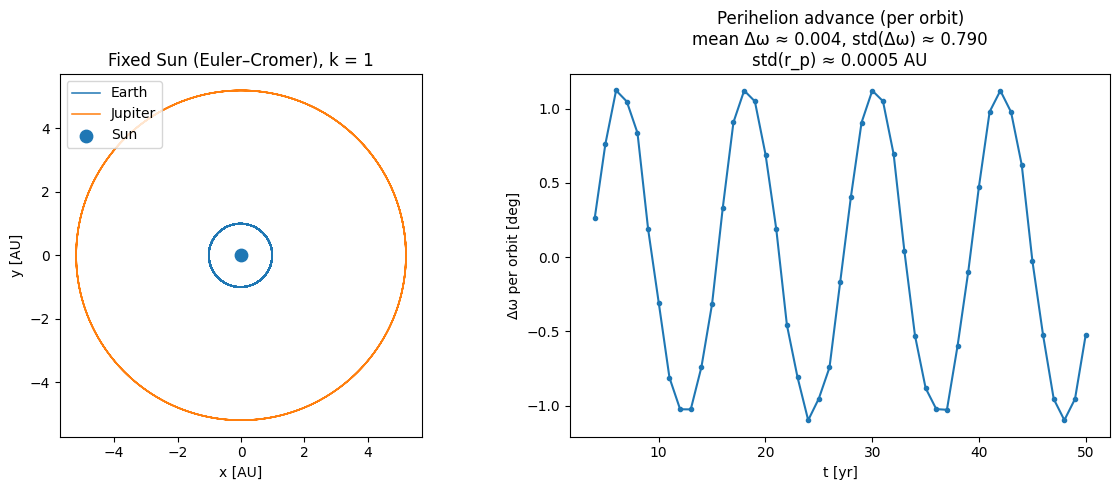

k=    1: mean Δω = 0.00357 deg/orbit, std(Δω) = 0.78990, std(rp) = 0.00050


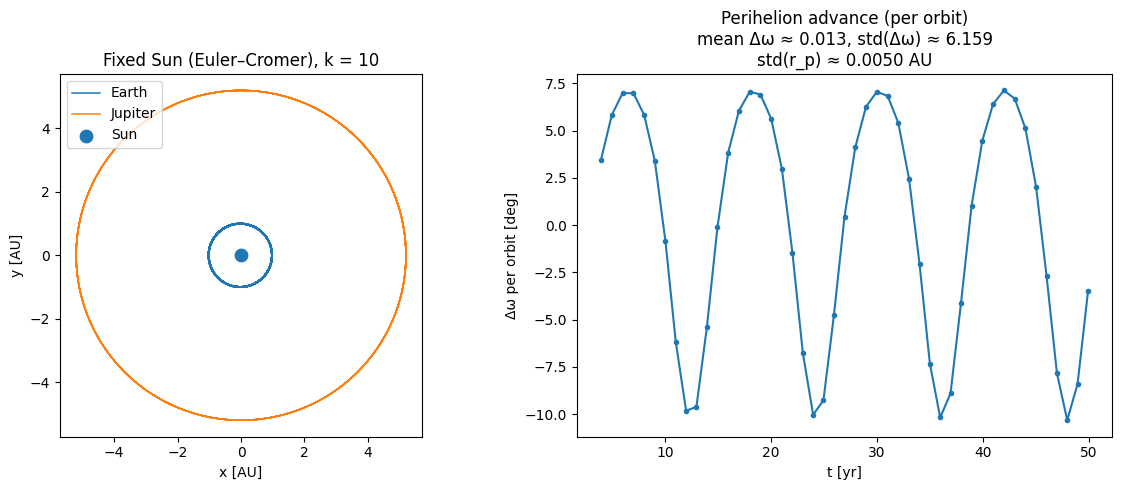

k=   10: mean Δω = 0.01344 deg/orbit, std(Δω) = 6.15883, std(rp) = 0.00500


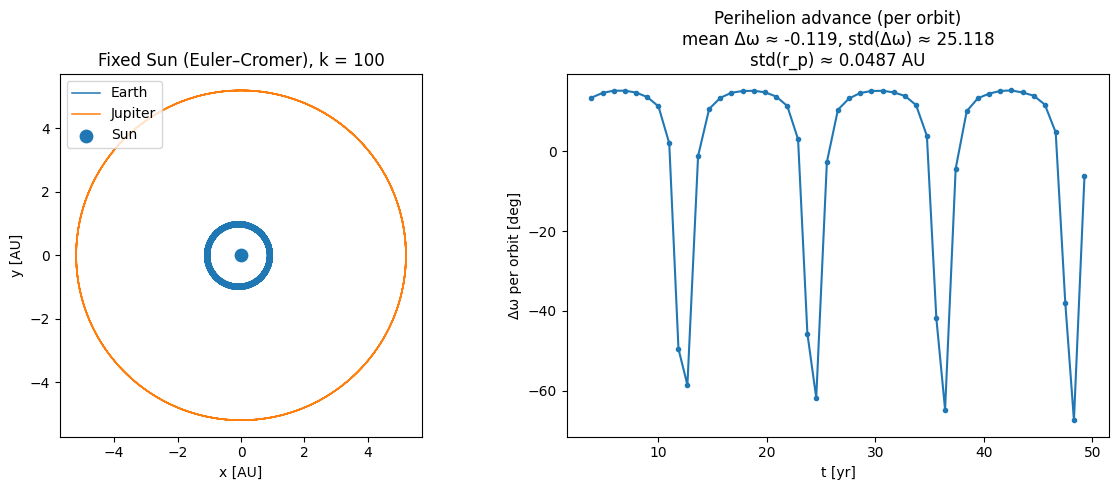

k=  100: mean Δω = -0.11915 deg/orbit, std(Δω) = 25.11760, std(rp) = 0.04867


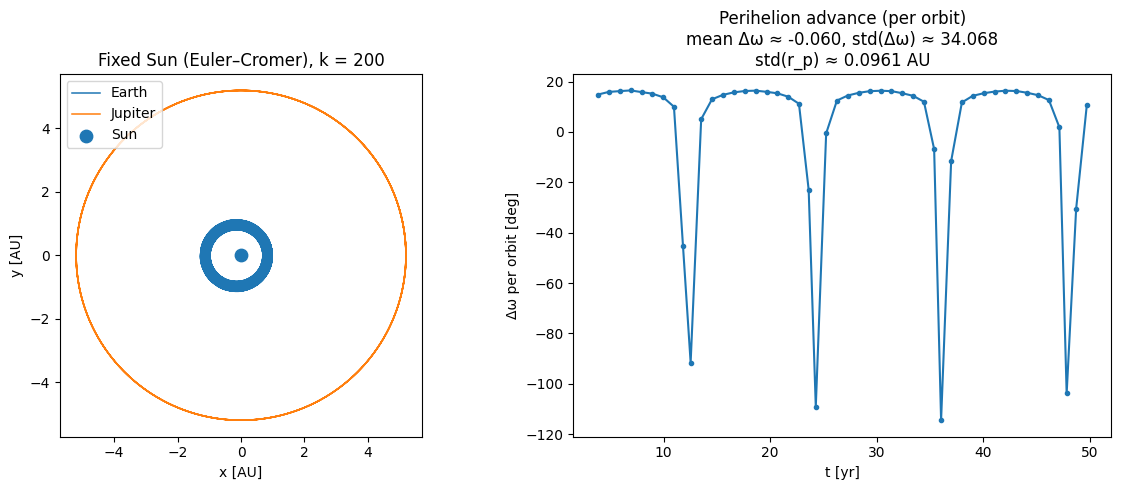

k=  200: mean Δω = -0.05997 deg/orbit, std(Δω) = 34.06769, std(rp) = 0.09606


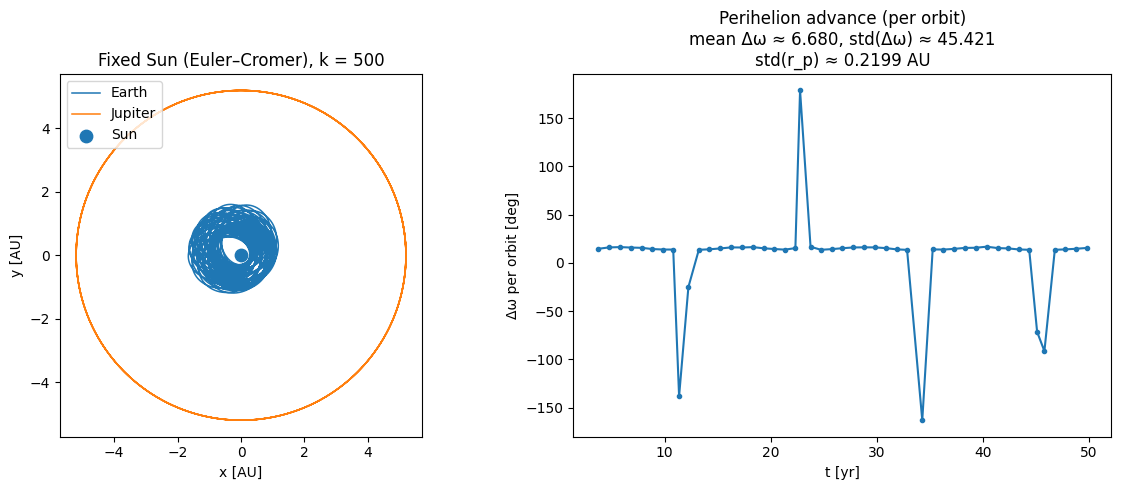

k=  500: mean Δω = 6.67978 deg/orbit, std(Δω) = 45.42073, std(rp) = 0.21986


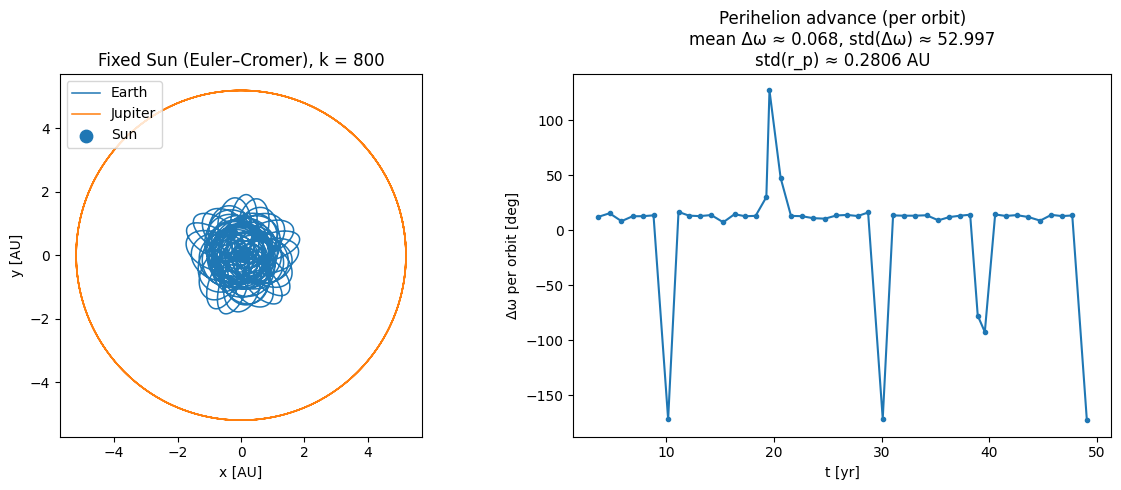

k=  800: mean Δω = 0.06812 deg/orbit, std(Δω) = 52.99739, std(rp) = 0.28056


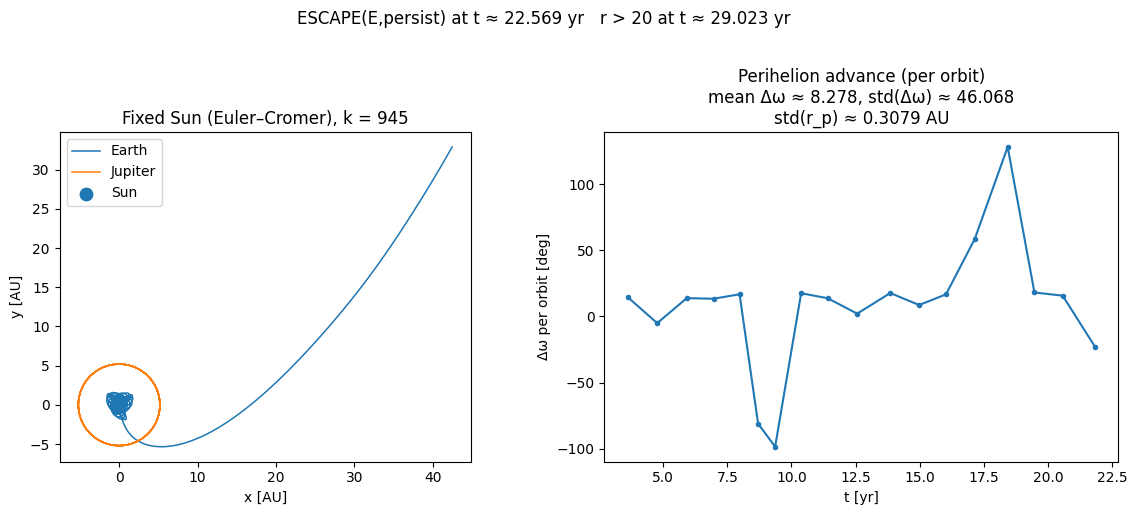

k=  945: mean Δω = 8.27787 deg/orbit, std(Δω) = 46.06787, std(rp) = 0.30788  >>> ESCAPE(E,persist) at t ≈ 22.569 yr  >>> r > 20 at t ≈ 29.023 yr


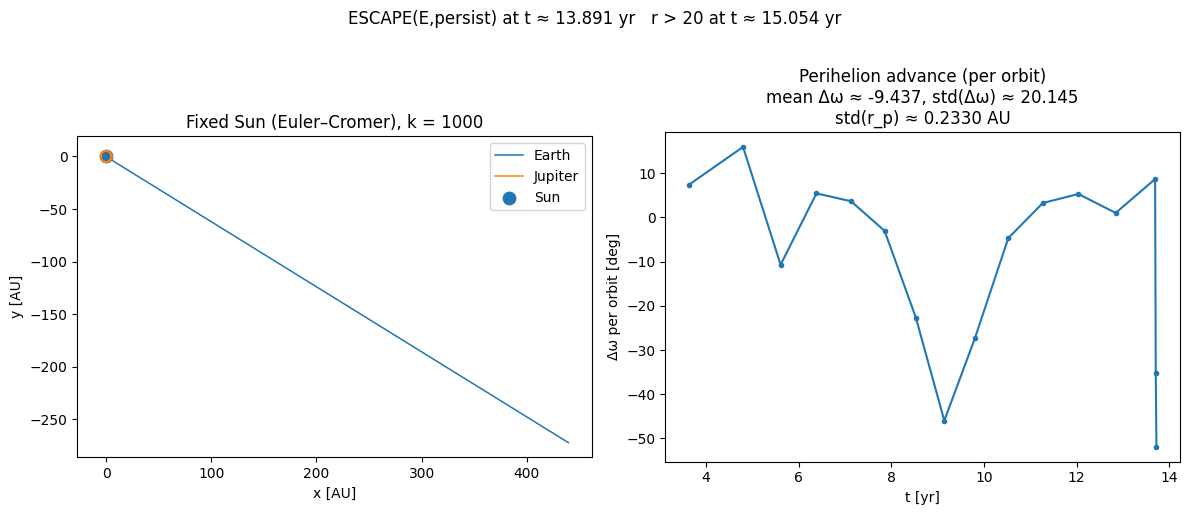

k= 1000: mean Δω = -9.43656 deg/orbit, std(Δω) = 20.14532, std(rp) = 0.23298  >>> ESCAPE(E,persist) at t ≈ 13.891 yr  >>> r > 20 at t ≈ 15.054 yr

Summary (energy-based escape with persistence is the primary physics criterion):
   k     mean_domega   std_domega     std_rp     esc_energy   t_escE     esc_r>R    t_r>R
    1      0.00357     0.78990    0.00050     False          —     False          —
   10      0.01344     6.15883    0.00500     False          —     False          —
  100     -0.11915    25.11760    0.04867     False          —     False          —
  200     -0.05997    34.06769    0.09606     False          —     False          —
  500      6.67978    45.42073    0.21986     False          —     False          —
  800      0.06812    52.99739    0.28056     False          —     False          —
  945      8.27787    46.06787    0.30788      True     22.569      True     29.023
 1000     -9.43656    20.14532    0.23298      True     13.891      True     15.054


In [ ]:
# Part 1 (Fixed Sun)

import numpy as np;
import matplotlib.pyplot as plt;

# Controls
PI = np.pi;
G  = 4.0 * PI**2;
mode = "fixed";
k_list = [1, 10, 100, 200, 500, 800, 945, 1000];
t_end = 50.0;
dt    = 2e-4;
earth_e = 0.017;
jupiter_r = 5.20;
jupiter_phase = 0.0;

# Escape / ejection criteria
eject_R = 20.0;
escape_r_min_for_energy = 2.0;
escape_persist_steps = 300;      # require eps>0 & vr>0 for this many consecutive steps
skip_orbits_for_fit = 3;         # ignore early perihelia as transient

# Masses
M_sun_kg = 1.99e30;
mE_kg    = 5.97e24;
mJ_kg    = 1.90e27;
mE = mE_kg / M_sun_kg;
mJ = mJ_kg / M_sun_kg;

# Map angle to (-pi, pi]
def wrap_to_pi(angle_rad):
    return (angle_rad + PI) % (2.0 * PI) - PI;

# Detect perihelia of Earth orbit relative to the Sun position
def perihelion_stats(t, xE, yE, xS = None, yS = None, skip = 3):
    if xS is None:
        xrel, yrel = xE, yE;
    else:
        xrel, yrel = xE - xS, yE - yS;

    r = np.hypot(xrel, yrel);

    # local minima: r[i-1] > r[i] < r[i+1]
    i = np.where((r[1:-1] < r[:-2]) & (r[1:-1] < r[2:]))[0] + 1;
    if len(i) < (skip + 4):
        return {"n_peri": max(0, len(i) - skip), "mean_domega_deg": np.nan, "std_domega_deg": np.nan, "std_rp": np.nan, "peri_t": np.array([]),
                "peri_theta": np.array([]), "peri_r": np.array([]), "domega_deg": np.array([]), "domega_t": np.array([]),};

    theta = np.arctan2(yrel[i], xrel[i]);
    rp = r[i];
    tperi = t[i];

    # skip transient perihelia
    theta2 = theta[skip:];
    rp2    = rp[skip:];
    t2     = tperi[skip:];
    dtheta = wrap_to_pi(np.diff(theta2));
    domega_deg = dtheta * 180.0 / PI;
    domega_t   = t2[1:];     # align with "after each orbit"

    return {"n_peri": len(theta2), "mean_domega_deg": float(np.mean(domega_deg)) if len(domega_deg) else np.nan,
            "std_domega_deg":  float(np.std(domega_deg))  if len(domega_deg) else np.nan, "std_rp":          float(np.std(rp2)),
            "peri_t": t2, "peri_theta": theta2, "peri_r": rp2, "domega_deg": domega_deg, "domega_t": domega_t,};

# Euler–Cromer - Fixed Sun
def euler_cromer_fixed(k, t_end, dt, earth_e, jupiter_r, jupiter_phase):
    n = int(np.ceil(t_end / dt));
    t = np.linspace(0.0, n*dt, n+1);
    mS  = 1.0;
    mJk = mJ * k;
    xE = np.zeros(n+1); yE = np.zeros(n+1);
    xJ = np.zeros(n+1); yJ = np.zeros(n+1);

    # Earth at perihelion on +x, tangential +y
    aE = 1.0;
    rE0 = aE*(1.0 - earth_e);
    vE0 = np.sqrt(G*mS*(1.0 + earth_e)/(aE*(1.0 - earth_e)));
    xE[0], yE[0] = rE0, 0.0;
    vEx, vEy = 0.0, vE0;

    # Jupiter approx circular, phase set
    xJ[0] = jupiter_r*np.cos(jupiter_phase);
    yJ[0] = jupiter_r*np.sin(jupiter_phase);

    # circular speed around Sun-only
    vJ0 = np.sqrt(G*mS/jupiter_r);
    vJx = -vJ0*np.sin(jupiter_phase);
    vJy =  vJ0*np.cos(jupiter_phase);

    # Escape flags
    esc_r = False;   t_r = None;

    esc_energy = False;  t_escE = None;
    persist_count = 0;

    # mu for Sun–Earth two-body energy diagnostic
    mu = G*(mS + mE);

    for i in range(n):
        # distances at step i
        rES = np.hypot(xE[i], yE[i]);
        rJS = np.hypot(xJ[i], yJ[i]);
        dx = xE[i] - xJ[i];
        dy = yE[i] - yJ[i];
        rEJ = np.hypot(dx, dy);

        # Accelerations (Sun fixed at origin)
        # Earth: Sun + Jupiter
        aEx = -G*mS*xE[i]/(rES**3) - G*mJk*dx/(rEJ**3);
        aEy = -G*mS*yE[i]/(rES**3) - G*mJk*dy/(rEJ**3);
        # Jupiter: Sun + Earth
        aJx = -G*mS*xJ[i]/(rJS**3) - G*mE*(-dx)/(rEJ**3);
        aJy = -G*mS*yJ[i]/(rJS**3) - G*mE*(-dy)/(rEJ**3);
        # Euler–Cromer velocity update
        vEx += dt*aEx;
        vEy += dt*aEy;
        vJx += dt*aJx;
        vJy += dt*aJy;
        # Euler–Cromer position update using new velocities
        xE[i+1] = xE[i] + dt*vEx;
        yE[i+1] = yE[i] + dt*vEy;
        xJ[i+1] = xJ[i] + dt*vJx;
        yJ[i+1] = yJ[i] + dt*vJy;

        # Earth-Sun distance at i+1
        rES_new = np.hypot(xE[i+1], yE[i+1]);

        # distance-based ejection
        if (not esc_r) and (rES_new > eject_R):
            esc_r = True;
            t_r = t[i+1];

        # Energy-based escape -> eps = v^2/2 - mu/r  &&  require eps>0 and moving outward (vr>0)
        if (not esc_energy) and (rES_new > escape_r_min_for_energy):
            v2  = vEx*vEx + vEy*vEy;
            eps = 0.5*v2 - mu/rES_new;

            # radial velocity wrt Sun (Sun fixed): vr = (r·v)/|r|
            vr = (xE[i+1]*vEx + yE[i+1]*vEy) / max(rES_new, 1e-15);

            if (eps > 0.0) and (vr > 0.0):
                persist_count += 1;
            else:
                persist_count = 0;

            if persist_count >= escape_persist_steps:
                esc_energy = True;
                t_escE = t[i+1];

    return t, xE, yE, xJ, yJ, esc_energy, t_escE, esc_r, t_r;


# Runner + plotter
def run(k):
    t, xE, yE, xJ, yJ, esc_energy, t_escE, esc_r, t_r = euler_cromer_fixed(k, t_end, dt, earth_e, jupiter_r, jupiter_phase);

    stats = perihelion_stats(t, xE, yE, xS = None, yS = None, skip = skip_orbits_for_fit);

    fig, ax = plt.subplots(1,2, figsize = (12,5));
    ax0, ax1 = ax;
    ax0.plot(xE, yE, lw = 1.1, label = "Earth");
    ax0.plot(xJ, yJ, lw = 1.1, label = "Jupiter");
    ax0.scatter([0],[0], s = 80, label = "Sun");
    ax0.set_aspect("equal", adjustable = "box");
    ax0.set_xlabel("x [AU]"); ax0.set_ylabel("y [AU]");
    ax0.set_title(f"Fixed Sun (Euler–Cromer), k = {k}");
    ax0.legend();

    if len(stats["domega_t"]) > 0:
        ax1.plot(stats["domega_t"], stats["domega_deg"], marker = "o", ms = 3);
        ax1.set_xlabel("t [yr]");
        ax1.set_ylabel("Δω per orbit [deg]");
        ax1.set_title(f"Perihelion advance (per orbit)\n"
            f"mean Δω ≈ {stats['mean_domega_deg']:.3f}, std(Δω) ≈ {stats['std_domega_deg']:.3f}\n"
            f"std(r_p) ≈ {stats['std_rp']:.4f} AU");
    else:
        ax1.text(0.1, 0.5, "Perihelia not cleanly detected\n(try smaller dt / longer t_end)", transform = ax1.transAxes);

    # Ask GPT to annotate escapes
    subtitle = "";
    if esc_energy:
        subtitle += f"ESCAPE(E,persist) at t ≈ {t_escE:.3f} yr   ";
    if esc_r:
        subtitle += f"r > {eject_R:g} at t ≈ {t_r:.3f} yr";
    if subtitle:
        fig.suptitle(subtitle, y = 1.02);

    plt.tight_layout();
    plt.show();

    return stats, {"esc_energy": esc_energy, "t_escE": t_escE, "esc_r": esc_r, "t_r": t_r};


# Sweep
print(f"Running mode = '{mode}' using Euler–Cromer with dt = {dt}, t_end = {t_end} yr ...\n");

results = [];
for k in k_list:
    stats, esc = run(k);

    results.append((k, stats["mean_domega_deg"], stats["std_domega_deg"], stats["std_rp"], esc["esc_energy"], esc["t_escE"],
                    esc["esc_r"], esc["t_r"],));

    msg = (f"k={k:>5}: mean Δω = {stats['mean_domega_deg']:.5f} deg/orbit, "
           f"std(Δω) = {stats['std_domega_deg']:.5f}, std(rp) = {stats['std_rp']:.5f}");
    if esc["esc_energy"]:
        msg += f"  >>> ESCAPE(E,persist) at t ≈ {esc['t_escE']:.3f} yr";
    if esc["esc_r"]:
        msg += f"  >>> r > {eject_R:g} at t ≈ {esc['t_r']:.3f} yr";
    print(msg);

print("\nSummary (energy-based escape with persistence is the primary physics criterion):");
print("   k     mean_domega   std_domega     std_rp     esc_energy   t_escE     esc_r>R    t_r>R");
for (k, md, sd, srp, eE, tE, eR, tR) in results:
    tE_str = "—" if tE is None else f"{tE:6.3f}";
    tR_str = "—" if tR is None else f"{tR:6.3f}";
    print(f"{k:5d}  {md:11.5f}  {sd:10.5f}  {srp:9.5f}     {str(eE):>5}     {tE_str:>6}     {str(eR):>5}     {tR_str:>6}");

# EOF



Running MOBILE 3-body (Euler–Cromer) with dt = 0.0002, t_end = 100.0 yr ...



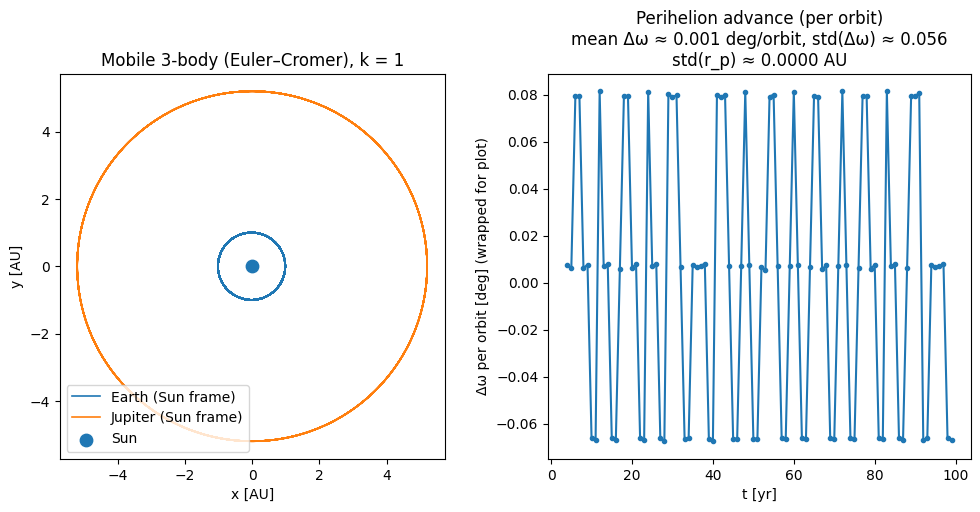

k =     1: mean Δω = 0.00147 deg/orbit, std(Δω) = 0.05619, std(rp) = 0.00001


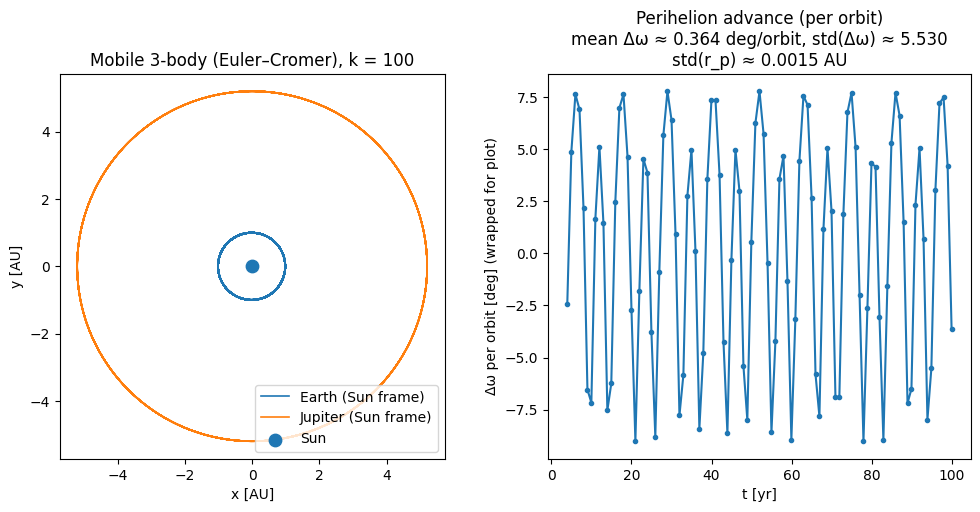

k =   100: mean Δω = 0.36444 deg/orbit, std(Δω) = 5.53002, std(rp) = 0.00147


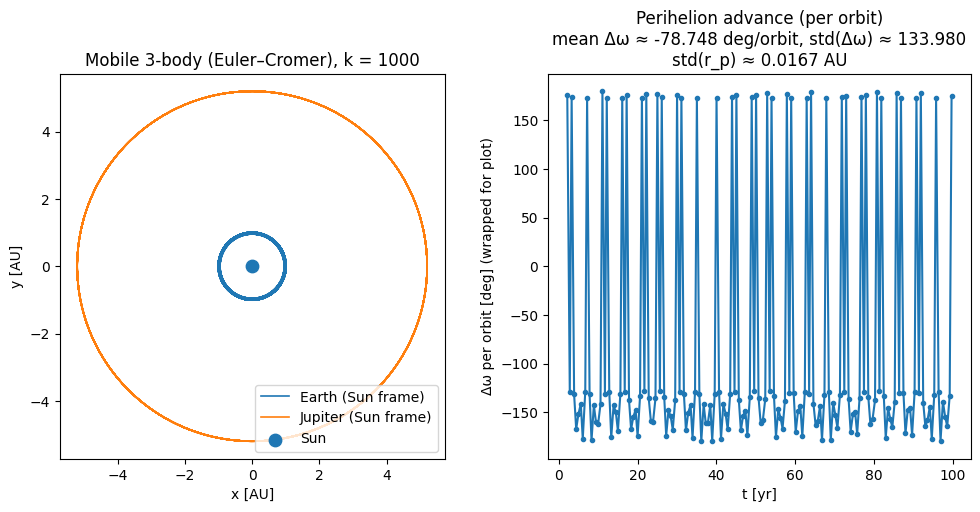

k =  1000: mean Δω = -78.74771 deg/orbit, std(Δω) = 133.98015, std(rp) = 0.01672


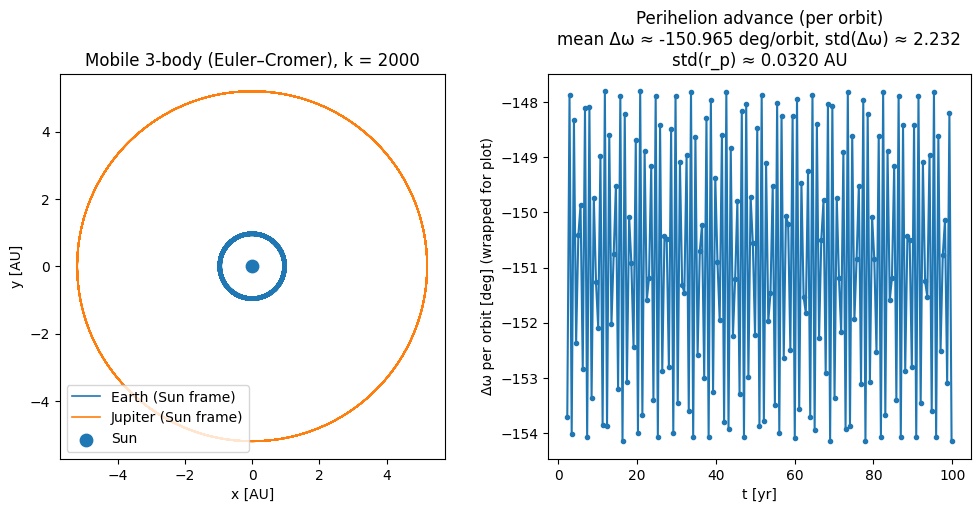

k =  2000: mean Δω = -150.96496 deg/orbit, std(Δω) = 2.23219, std(rp) = 0.03196


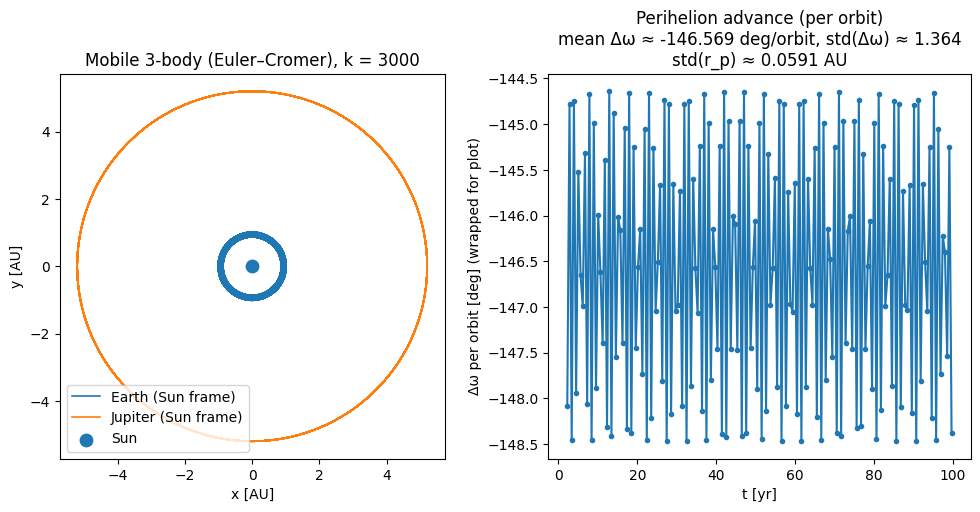

k =  3000: mean Δω = -146.56940 deg/orbit, std(Δω) = 1.36402, std(rp) = 0.05914


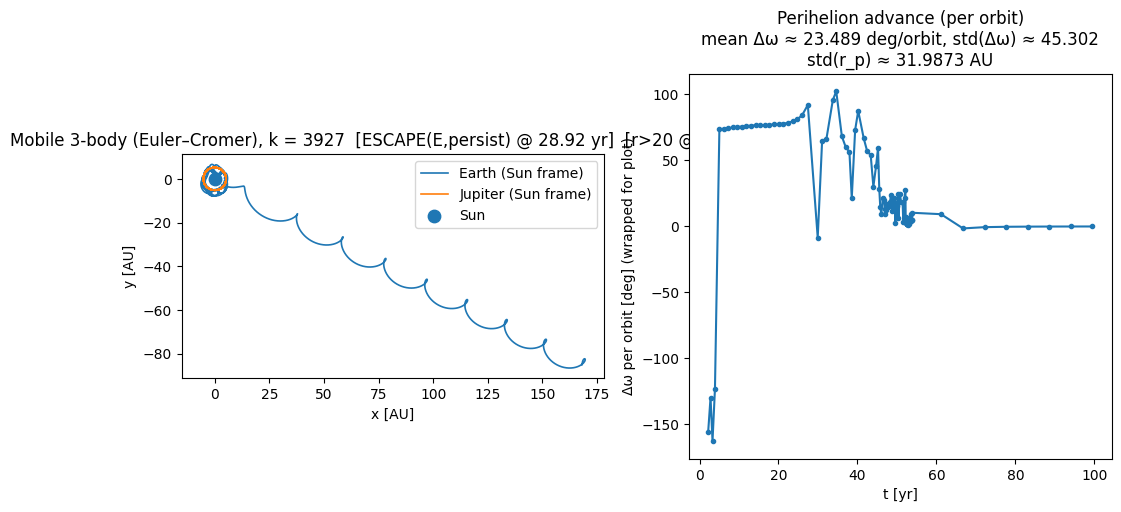

k =  3927: mean Δω = 23.48948 deg/orbit, std(Δω) = 45.30186, std(rp) = 31.98730  >>> ESCAPE(E,persist) at t ≈ 28.920 yr  >>> r>20 at t ≈ 57.136 yr


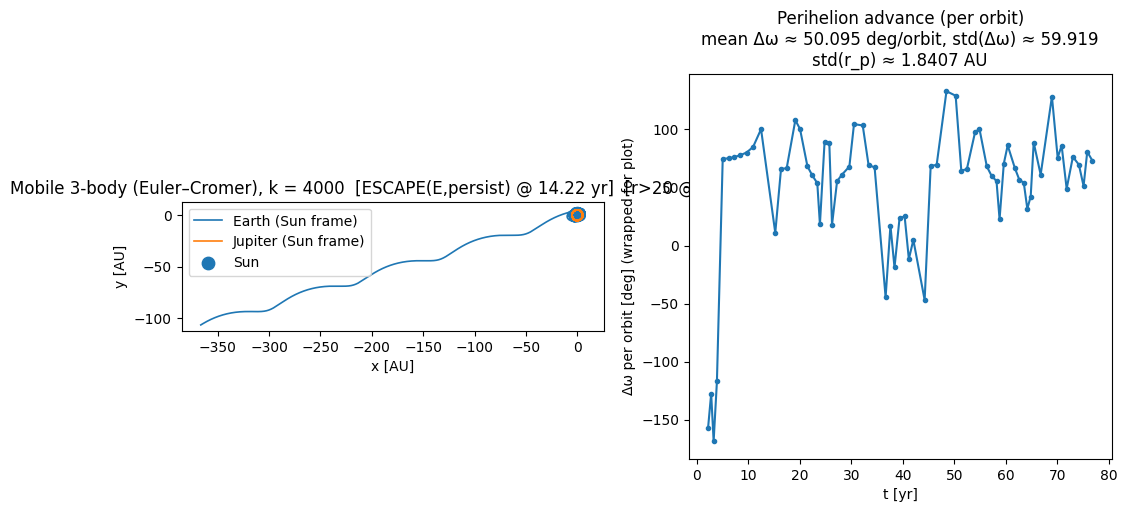

k =  4000: mean Δω = 50.09493 deg/orbit, std(Δω) = 59.91876, std(rp) = 1.84065  >>> ESCAPE(E,persist) at t ≈ 14.221 yr  >>> r>20 at t ≈ 77.700 yr

Summary (energy-based escape WITH persistence is the primary physics criterion):
   k     mean_domega   std_domega     std_rp     esc_energy   t_escE     esc_r>R    t_r>R
    1      0.00147     0.05619    0.00001     False          —     False          —
  100      0.36444     5.53002    0.00147     False          —     False          —
 1000    -78.74771   133.98015    0.01672     False          —     False          —
 2000   -150.96496     2.23219    0.03196     False          —     False          —
 3000   -146.56940     1.36402    0.05914     False          —     False          —
 3927     23.48948    45.30186   31.98730      True     28.920      True     57.136
 4000     50.09493    59.91876    1.84065      True     14.221      True     77.700


In [ ]:
# Part 2 (Mobile Sun)

import numpy as np;
import matplotlib.pyplot as plt;

# User controls
PI = np.pi;
G  = 4.0 * PI**2;
k_list = [1, 100, 1000, 2000, 3000, 3927, 4000];
t_end = 100.0;
dt    = 2e-4;
earth_e = 0.017;
jupiter_r = 5.20;
jupiter_phase = 0.0;
eject_R = 20.0;        # pragmatic "definitely gone" distance threshold
escape_r_min_for_energy = 2.0;  # don't trigger energy escape at tiny radii

escape_persist_steps = 500;
skip_orbits_for_fit = 3;     # ignore early perihelia

# Masses
M_sun_kg = 1.99e30;
mE_kg    = 5.97e24;
mJ_kg    = 1.90e27;
mE = mE_kg / M_sun_kg;
mJ = mJ_kg / M_sun_kg;

# Map angle to (-pi, pi]
def wrap_to_pi(angle_rad):
    return (angle_rad + PI) % (2.0 * PI) - PI;

# Detect perihelia and compute per-orbit perihelion advance. Unwrap theta sequence BEFORE differencing to avoid +/-pi branch-cut stuff.
def perihelion_stats(t, xE, yE, xS = None, yS = None, skip = 3):
    if xS is None:
        xrel, yrel = xE, yE;
    else:
        xrel, yrel = xE - xS, yE - yS;

    r = np.hypot(xrel, yrel);

    # local minima in r: r[i-1] > r[i] < r[i+1]
    i = np.where((r[1:-1] < r[:-2]) & (r[1:-1] < r[2:]))[0] + 1;
    if len(i) < (skip + 4):
        return {"n_peri": max(0, len(i) - skip), "mean_domega_deg": np.nan, "std_domega_deg": np.nan, "std_rp": np.nan, "peri_t": np.array([]),
            "peri_theta": np.array([]), "peri_r": np.array([]), "domega_deg_plot": np.array([]), "domega_t": np.array([]),};

    theta = np.arctan2(yrel[i], xrel[i]);  # in (-pi, pi]
    rp = r[i];
    tperi = t[i];

    # skip transients
    theta2 = theta[skip:];
    rp2 = rp[skip:];
    t2 = tperi[skip:];
    # Unwrap BEFORE differencing
    theta2_unwrap = np.unwrap(theta2);
    dtheta_unwrap = np.diff(theta2_unwrap);
    domega_deg = dtheta_unwrap * 180.0 / PI;
    # Wrap the per-orbit increments to (-180, 180]
    domega_deg_plot = wrap_to_pi(dtheta_unwrap) * 180.0 / PI;

    domega_t = t2[1:];  # aligns to second perihelion onward

    return {"n_peri": len(theta2), "mean_domega_deg": np.mean(domega_deg), "std_domega_deg": np.std(domega_deg), "std_rp": np.std(rp2),
        "peri_t": t2, "peri_theta": theta2_unwrap, "peri_r": rp2, "domega_deg_plot": domega_deg_plot, "domega_t": domega_t,};

# Euler Cromer - Mobile
def euler_cromer_mobile_3body(k, t_end, dt, earth_e = 0.017, jupiter_r = 5.20, jupiter_phase = 0.0):
    n = int(np.ceil(t_end / dt));
    t = np.linspace(0.0, n*dt, n+1);
    mS = 1.0;
    mJk = mJ * k;
    masses = np.array([mS, mE, mJk], dtype = float);
    Mtot = masses.sum();

    # Positions over time
    r = np.zeros((3, n+1, 2), dtype = float);
    # Initial positions
    aE = 1.0;
    rE0 = aE*(1.0 - earth_e);
    r[0,0,:] = [0.0, 0.0];
    r[1,0,:] = [rE0, 0.0];
    r[2,0,:] = [jupiter_r*np.cos(jupiter_phase), jupiter_r*np.sin(jupiter_phase)];

    # Tangential directions -> Sun-relative
    tE_hat = np.array([0.0, 1.0]);  # Earth at perihelion on +x -> +y
    tJ_hat = np.array([-np.sin(jupiter_phase), np.cos(jupiter_phase)]);
    # Nominal relative speeds -> about the Sun
    vE_rel = np.sqrt(G*(mS)*(1.0 + earth_e)/(aE*(1.0 - earth_e)));
    vJ_rel = np.sqrt(G*(mS + mJk)/jupiter_r);
    # Momentum-zero: choose vS so total momentum = 0;
    vS = -(mE*vE_rel*tE_hat + mJk*vJ_rel*tJ_hat) / Mtot
    vE = vS + vE_rel*tE_hat;
    vJ = vS + vJ_rel*tJ_hat;

    v = np.zeros((3, 2), dtype = float);
    v[0,:] = vS;
    v[1,:] = vE;
    v[2,:] = vJ;

    # Shift COM position to origin
    Rcom = (masses[0]*r[0,0,:] + masses[1]*r[1,0,:] + masses[2]*r[2,0,:]) / Mtot;
    r[:,0,:] -= Rcom;

    def accel_all(r_now):
        a = np.zeros_like(r_now);
        for i in range(3):
            for j in range(3):
                if i == j:
                    continue
                dx = r_now[j,0] - r_now[i,0];
                dy = r_now[j,1] - r_now[i,1];
                rij = np.hypot(dx, dy);
                a[i,0] += G*masses[j]*dx/(rij**3);
                a[i,1] += G*masses[j]*dy/(rij**3);
        return a;

    # Escape flags
    esc_energy = False; t_escE = None; esc_r = False; t_r = None;
    # persistence counter for energy-based escape
    persist_count = 0;

    # Euler–Cromer loop: v_{n+1} = v_n + a(r_n) dt; r_{n+1} = r_n + v_{n+1} dt
    for i in range(n):
        a = accel_all(r[:,i,:]);
        # v first
        v = v + dt*a;
        # r next
        r[:,i+1,:] = r[:,i,:] + dt*v;

        # Earth-Sun relative vectors at the new time
        rES_vec = r[1,i+1,:] - r[0,i+1,:];
        vES_vec = v[1,:] - v[0,:];
        rES = np.hypot(rES_vec[0], rES_vec[1]);

        # Distance-based ejection
        if (not esc_r) and (rES > eject_R):
            esc_r = True;
            t_r = t[i+1];

        # Energy-based escape (heliocentric two-body), WITH persistence
        mu = G*(masses[0] + masses[1]);
        v2 = vES_vec[0]**2 + vES_vec[1]**2;
        eps = 0.5*v2 - mu/rES;
        vr = (rES_vec[0]*vES_vec[0] + rES_vec[1]*vES_vec[1]) / max(rES, 1e-15);

        cond = (rES > escape_r_min_for_energy) and (eps > 0.0) and (vr > 0.0);

        if (not esc_energy):
            if cond:
                persist_count += 1;
                if persist_count >= escape_persist_steps:
                    esc_energy = True;
                    t_escE = t[i+1];
            else:
                persist_count = 0;

    xS, yS = r[0,:,0], r[0,:,1];
    xE, yE = r[1,:,0], r[1,:,1];
    xJ, yJ = r[2,:,0], r[2,:,1];

    return t, xE, yE, xJ, yJ, xS, yS, esc_energy, t_escE, esc_r, t_r;


# Runner + plotting
def run(k):
    t, xE, yE, xJ, yJ, xS, yS, esc_energy, t_escE, esc_r, t_r = euler_cromer_mobile_3body(k = k, t_end = t_end, dt = dt, earth_e = earth_e,
        jupiter_r = jupiter_r, jupiter_phase = jupiter_phase);

    stats = perihelion_stats(t, xE, yE, xS = xS, yS = yS, skip = skip_orbits_for_fit);

    # Plot in Sun frame for readability
    xErel, yErel = xE - xS, yE - yS;
    xJrel, yJrel = xJ - xS, yJ - yS;

    title_extra = "";
    if esc_energy:
      title_extra += f"  [ESCAPE(E,persist) @ {t_escE:.2f} yr]";
    if esc_r:
      title_extra += f"  [r>{eject_R:g} @ {t_r:.2f} yr]";

    fig, ax = plt.subplots(1,2, figsize = (12,5));
    ax0, ax1 = ax;

    ax0.plot(xErel, yErel, lw = 1.2, label = "Earth (Sun frame)");
    ax0.plot(xJrel, yJrel, lw = 1.2, label = "Jupiter (Sun frame)");
    ax0.scatter([0],[0], s = 80, label = "Sun");
    ax0.set_aspect("equal", adjustable = "box");
    ax0.set_xlabel("x [AU]"); ax0.set_ylabel("y [AU]");
    ax0.set_title(f"Mobile 3-body (Euler–Cromer), k = {k}{title_extra}");
    ax0.legend();

    if len(stats["domega_t"]) > 0:
      ax1.plot(stats["domega_t"], stats["domega_deg_plot"], marker = "o", ms = 3);
      ax1.set_xlabel("t [yr]");
      ax1.set_ylabel("Δω per orbit [deg] (wrapped for plot)");
      ax1.set_title(f"Perihelion advance (per orbit)\n"
                    f"mean Δω ≈ {stats['mean_domega_deg']:.3f} deg/orbit, std(Δω) ≈ {stats['std_domega_deg']:.3f}\n"
                    f"std(r_p) ≈ {stats['std_rp']:.4f} AU");
    plt.show();

    return stats, esc_energy, t_escE, esc_r, t_r;

# Sweep
print(f"Running MOBILE 3-body (Euler–Cromer) with dt = {dt}, t_end = {t_end} yr ...\n");
results = [];
for k in k_list:
    stats, esc_energy, t_escE, esc_r, t_r = run(k);
    results.append((k, stats["mean_domega_deg"], stats["std_domega_deg"], stats["std_rp"], esc_energy, t_escE, esc_r, t_r))

    msg = (f"k = {k:>5}: mean Δω = {stats['mean_domega_deg']:.5f} deg/orbit, "
           f"std(Δω) = {stats['std_domega_deg']:.5f}, std(rp) = {stats['std_rp']:.5f}");
    if esc_energy:
        msg += f"  >>> ESCAPE(E,persist) at t ≈ {t_escE:.3f} yr";
    if esc_r:
        msg += f"  >>> r>{eject_R:g} at t ≈ {t_r:.3f} yr";
    print(msg);

print("\nSummary (energy-based escape WITH persistence is the primary physics criterion):");
print("   k     mean_domega   std_domega     std_rp     esc_energy   t_escE     esc_r>R    t_r>R");
for (k, md, sd, srp, eE, tE, eR, tR) in results:
    tE_str = "—" if tE is None else f"{tE:6.3f}";
    tR_str = "—" if tR is None else f"{tR:6.3f}";
    print(f"{k:5d}  {md:11.5f}  {sd:10.5f}  {srp:9.5f}     {str(eE):>5}     {tE_str:>6}     {str(eR):>5}     {tR_str:>6}");


# EOF


